In [1]:
import os
from pathlib import Path
from sentence_transformers import SentenceTransformer
from utils.utils import load_data, get_collection

In [2]:
curr_dir = Path(os.getcwd())
data_dir = curr_dir / 'data'
data_pickle_path = data_dir / 'data_set.pkl'
vectordb_dir = curr_dir / 'vectore_storage'
chroma_dir = vectordb_dir / 'chroma'
for dir in [data_dir, vectordb_dir, chroma_dir]:
    if not os.path.exists(dir):
        os.mkdir(dir)

In [3]:
data_set = load_data(data_pickle_path)

Data set already exists in the local drive. Loading it.


In [4]:
#Load CLIP model
model = SentenceTransformer("sentence-transformers/clip-ViT-L-14")

In [5]:
collection = get_collection(chroma_dir, model, collection_name='image_vectors', data=data_set['train']['image'])

Embeddings are already added to the collection.


In [7]:
query = "red car"
results = collection.query(
    # query_texts=["texts"],
    query_embeddings=model.encode([query]),
    n_results=2
    )
results

{'ids': [['image 284', 'image 322']],
 'distances': [[416.57818603515625, 417.813720703125]],
 'metadatas': [[None, None]],
 'embeddings': None,
 'documents': [[None, None]],
 'uris': None,
 'data': None}

In [8]:
threshold = 500
result = results['distances'][0][0] <= threshold
result

True

In [38]:
img_id = int(results['ids'][0][0].split('image ')[-1])
img_id

3

Description: there is a picture of a street with a red car driving down it


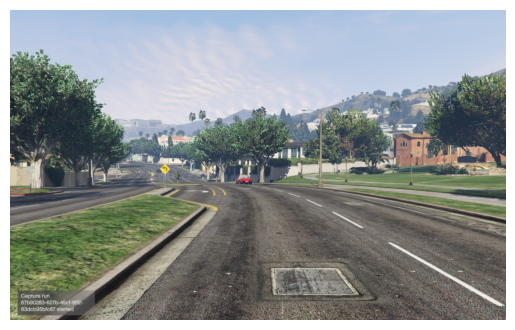

In [39]:
import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 6))
plt.axis("off")

image = data_set['train']['image'][img_id]
text = data_set['train']['text'][img_id]

plt.imshow(image)
print(f"Description: {text}")

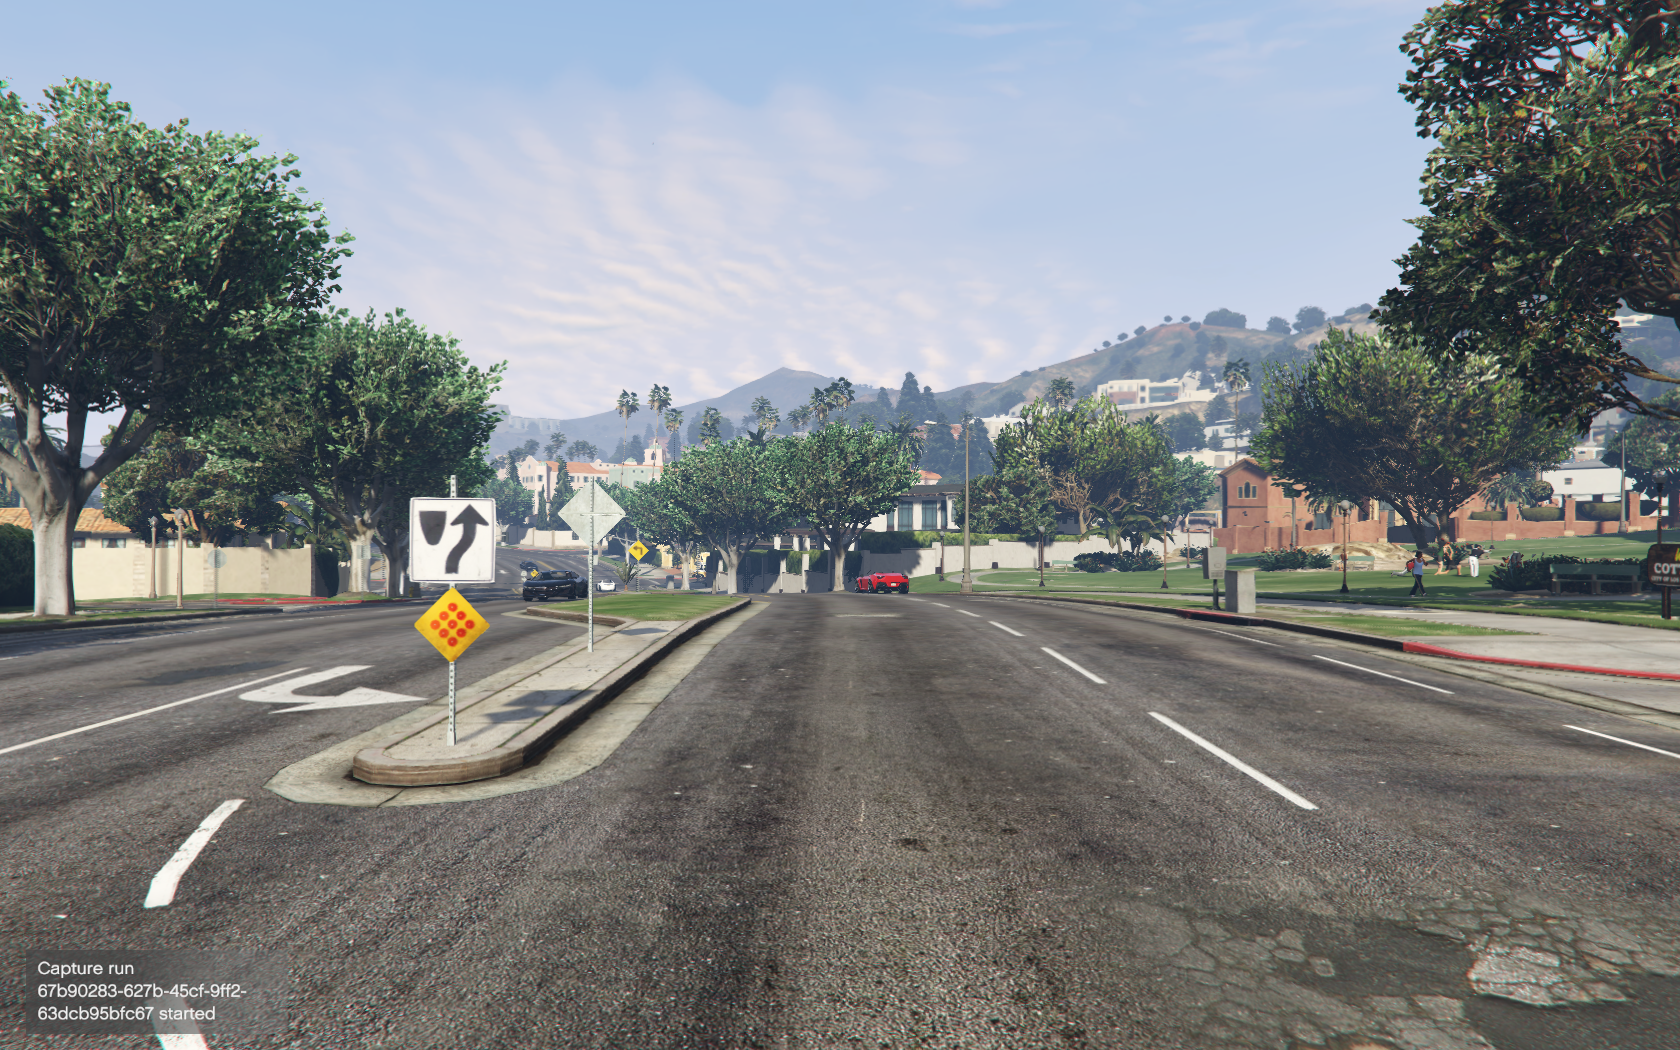

In [9]:
# data_set['train']['image'][img_id]